# 4/23

XOR 연산 문제

In [101]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt # 시각화

torch.manual_seed(42) # 재현성

In [102]:
# 데이터 준비

X_xor = torch.tensor([[0.0, 0.0],  # 0
                      [0.0, 1.0],  # 1
                      [1.0, 0.0],  # 1
                      [1.0, 1.0]]) # 0

y_xor = torch.tensor([[0.0],
                      [1.0],
                      [1.0],
                      [0.0]])

In [103]:
# 신경망

class  XORNet(nn.Module): # 기존꺼 상속
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2,4)
        self.output = nn.Linear(4,1)

    def forward(self, x): # forward = 'predict'랑 사실상 같은 의미 (예측!!)
        x = torch.relu(self.hidden(x)) # 은닉층의 결과에 활성화 함수 적용
        x = torch.sigmoid(self.output(x)) # 0과 1 사이로 압축
        return x    # 반환값
    
# 객체 만들기
model = XORNet()

# 학습 가능한 파라미터 수
for p in model.parameters():
    print(f'학습 가능한 파라미터 수: {p.numel()}')
    print(f'가중치 및 바이어스 값: {p}')

학습 가능한 파라미터 수: 8
가중치 및 바이어스 값: Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153]], requires_grad=True)
학습 가능한 파라미터 수: 4
가중치 및 바이어스 값: Parameter containing:
tensor([ 0.6233, -0.5188,  0.6146,  0.1323], requires_grad=True)
학습 가능한 파라미터 수: 4
가중치 및 바이어스 값: Parameter containing:
tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True)
학습 가능한 파라미터 수: 1
가중치 및 바이어스 값: Parameter containing:
tensor([0.3854], requires_grad=True)


In [104]:
 # 손실함수 / 바이어스 반영
criterion = nn.BCELoss()

# 최적화 옵티마이저 (가중치 업데이트)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [105]:
# 학습 : 단계별로 조금씩 여러번 해야함
# 경사하강법

epochs = 1000
loss_history = []
for epoch in range(epochs):
    # # [기울기 초기화] zero_grad()
    # optimizer.zero_grad()

    # [forward] 순전파: 값 예측
    predict = model (X_xor)

    # [loss 계산]
    loss = criterion(predict, y_xor) # loss는 값이 아니라 텐서 객체임, 자동미분 기능 있음

    # [기울기 초기화] zero_grad()
    optimizer.zero_grad()
    
    # [backward] 역전파(체이닝룰) 각 계산스템별 기울기 계산
    loss.backward()

    # [업데이트] 이전 기울기에 - backward 에서 구한 기울기
    optimizer.step()

    # loss_history에 loss 저장 (해도되고 안해도됨)
    loss_history.append(loss.item())
    if (epoch+1) % 200 == 0:
        print(f'epoch : {epoch+1 / epochs} loss : {loss.item()}')

epoch : 199.001 loss : 0.17800430953502655
epoch : 399.001 loss : 0.025707358494400978
epoch : 599.001 loss : 0.009478487074375153
epoch : 799.001 loss : 0.004902699496597052
epoch : 999.001 loss : 0.002985338680446148


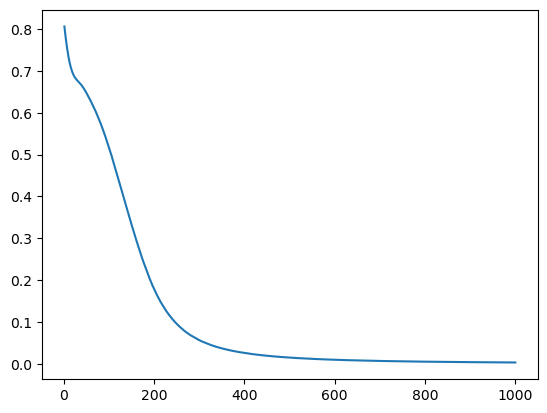

In [106]:
plt.plot(range(1, epochs+1), loss_history)
plt.show()

------

# 데이터 로드 연습

In [107]:
from sklearn.datasets import load_iris
X = torch.tensor(load_iris().data, dtype = torch.float32)
y = torch.tensor(load_iris().target, dtype = torch.long)

# 데이터셋 준비
train_dataset = TensorDataset(X_xor, y_xor)

# 데이터로더
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

이렇게 로드한 데이터를 위에서 만들어둔 파이프라인에 넣어줘야함

In [108]:
# 학습 : 단계별로 조금씩 여러번 해야함
# 경사하강법

epochs = 1000
loss_history = []
for epoch in range(epochs):
    for data in train_loader:
        # [기울기 초기화] zero_grad()
        optimizer.zero_grad()

        # [forward] 순전파: 값 예측
        predict = model (X_xor)

        # [loss 계산]
        loss = criterion(predict, y_xor) # loss는 값이 아니라 텐서 객체임, 자동미분 기능 있음

        # [backward] 역전파(체이닝룰) 각 계산스템별 기울기 계산
        loss.backward()

        # [업데이트] 이전 기울기에 - backward 에서 구한 기울기
        optimizer.step()

        # loss_history에 loss 저장 (해도되고 안해도됨)
        loss_history.append(loss.item())
        if (epoch+1) % 200 == 0:
            print(f'epoch : {epoch+1 / epochs} loss : {loss.item()}')

epoch : 199.001 loss : 0.0014253710396587849
epoch : 199.001 loss : 0.001423010602593422
epoch : 399.001 loss : 0.0008130818023346364
epoch : 399.001 loss : 0.0008120222482830286
epoch : 599.001 loss : 0.0005127228796482086
epoch : 599.001 loss : 0.0005122155416756868
epoch : 799.001 loss : 0.0003442243905737996
epoch : 799.001 loss : 0.0003439131542108953
epoch : 999.001 loss : 0.00024111184757202864
epoch : 999.001 loss : 0.00024090305669233203
